# Bài 5 — Tái lập cơ chế thích ứng Positional Embedding của AST

Positional embedding 2D pretrained của ViT/DeiT trên ảnh 384×384 có kích thước **(24, 24, 768)**. AST cần lưới positional embedding kích thước **(12, 100, 768)** để khớp với số patch của Spectrogram (128 mel-bin × ~1024 frame, patch 16, stride 10).

## Yêu cầu

1. **Cắt (crop)** trục tần số từ 24 xuống 12.
2. **Nội suy song tuyến tính (Bilinear Interpolation)** trục thời gian từ 24 lên 100.
3. Vẽ heatmap trực quan hoá ma trận vị trí **trước** và **sau** nội suy để chứng minh **tính liên tục không gian (spatial continuity)** được bảo toàn.

> Không cần checkpoint thật — dùng ma trận positional embedding **giả lập** để tập trung vào đúng phần thuật toán cắt + nội suy.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Kích thước lưới positional embedding gốc (ViT/DeiT 384x384, patch 16 -> 24x24 patch)
SRC_FREQ, SRC_TIME, EMBED_DIM = 24, 24, 768

# Kích thước lưới positional embedding mục tiêu cho AST
TGT_FREQ, TGT_TIME = 12, 100

## 2. Tạo ma trận positional embedding giả lập

Để heatmap "trước/sau" có ý nghĩa trực quan (chứng minh được tính liên tục chứ không chỉ là nhiễu ngẫu nhiên), ta mô phỏng một positional embedding **mượt theo không gian**: mỗi channel là tổ hợp vài hàm sin/cos tần số thấp theo 2 trục, cộng thêm một chút nhiễu nhỏ — giống hành vi thực tế của positional embedding học được (biến thiên mượt theo vị trí).

In [2]:
def make_synthetic_pos_embed(freq=SRC_FREQ, time=SRC_TIME, dim=EMBED_DIM, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    yy, xx = torch.meshgrid(
        torch.linspace(0, 2 * np.pi, freq),
        torch.linspace(0, 2 * np.pi, time),
        indexing="ij",
    )  # (freq, time)

    pos_embed = torch.zeros(freq, time, dim)
    # Mỗi channel dùng tần số + pha ngẫu nhiên khác nhau -> vẫn mượt nhưng đa dạng
    freqs_y = torch.rand(dim, generator=g) * 2 + 0.5
    freqs_x = torch.rand(dim, generator=g) * 2 + 0.5
    phases = torch.rand(dim, generator=g) * 2 * np.pi

    for c in range(dim):
        pos_embed[:, :, c] = torch.sin(freqs_y[c] * yy + freqs_x[c] * xx + phases[c])

    noise = torch.randn(freq, time, dim, generator=g) * 0.05
    return pos_embed + noise

pos_embed_src = make_synthetic_pos_embed()
print("Positional embedding gốc:", tuple(pos_embed_src.shape))

Positional embedding gốc: (24, 24, 768)


## 3. Cắt trục tần số (24 → 12)

In [3]:
def crop_frequency_axis(pos_embed, target_freq=TGT_FREQ):
    # =========================================================
    # TODO 1: CẮT (CROP) TRỤC TẦN SỐ VỀ ĐÚNG target_freq
    # - pos_embed có shape (freq, time, dim).
    # - Cắt LẤY PHẦN TRUNG TÂM theo trục tần số (axis 0), vì các patch tần
    #   số ở giữa thường mang thông tin vị trí "trung tính" hơn 2 đầu biên.
    # - Gợi ý: tính start = (freq - target_freq) // 2, rồi slice
    #   pos_embed[start:start + target_freq, :, :].
    # - Trả về tensor shape (target_freq, time, dim).
    # =========================================================
    # TODO 1
    freq = pos_embed.shape[0]
    start = (freq - target_freq) // 2
    cropped = pos_embed[start:start + target_freq, :, :]
    return cropped

pos_embed_freq_cropped = crop_frequency_axis(pos_embed_src)
print("Sau khi cắt trục tần số:", tuple(pos_embed_freq_cropped.shape))
assert pos_embed_freq_cropped.shape[0] == TGT_FREQ

Sau khi cắt trục tần số: (12, 24, 768)


## 4. Nội suy song tuyến tính trục thời gian (24 → 100)

In [4]:
def interpolate_time_axis(pos_embed, target_time=TGT_TIME):
    # =========================================================
    # TODO 2: NỘI SUY SONG TUYẾN TÍNH TRỤC THỜI GIAN
    # - pos_embed có shape (freq, target_time_gốc, dim) — ở đây freq đã là 12,
    #   trục thời gian vẫn đang là 24 (từ SRC_TIME), cần đưa lên target_time.
    # - F.interpolate yêu cầu input dạng (N, C, H, W). Cách làm:
    #     1) permute pos_embed về (dim, freq, time)   # xem dim như channel
    #     2) unsqueeze thêm batch dim -> (1, dim, freq, time)
    #     3) F.interpolate(..., size=(freq, target_time),
    #                       mode="bilinear", align_corners=False)
    #     4) squeeze(0) rồi permute lại về (freq, target_time, dim)
    # =========================================================
    # TODO 2
    freq, _, _ = pos_embed.shape

    x = pos_embed.permute(2, 0, 1).unsqueeze(0)  # (1, dim, freq, time)
    x = F.interpolate(
        x,
        size=(freq, target_time),
        mode="bilinear",
        align_corners=False,
    )
    interpolated = x.squeeze(0).permute(1, 2, 0)  # (freq, target_time, dim)
    return interpolated
    
pos_embed_time_interp = interpolate_time_axis(pos_embed_freq_cropped)
print("Sau khi nội suy trục thời gian:", tuple(pos_embed_time_interp.shape))
assert pos_embed_time_interp.shape == (TGT_FREQ, TGT_TIME, EMBED_DIM)

Sau khi nội suy trục thời gian: (12, 100, 768)


## 5. Kết hợp thành 1 hàm thích ứng hoàn chỉnh

In [5]:
def adapt_positional_embedding(pos_embed, target_freq=TGT_FREQ, target_time=TGT_TIME):
    # =========================================================
    # TODO 3: GHÉP 2 BƯỚC TRÊN THÀNH 1 PIPELINE HOÀN CHỈNH
    # - Gọi crop_frequency_axis rồi interpolate_time_axis.
    # - Trả về ma trận cuối cùng shape (target_freq, target_time, dim).
    # =========================================================
    # TODO 3
    freq_cropped = crop_frequency_axis(pos_embed, target_freq)
    adapted = interpolate_time_axis(freq_cropped, target_time)
    return adapted

pos_embed_ast = adapt_positional_embedding(pos_embed_src)
print("Positional embedding cho AST:", tuple(pos_embed_ast.shape))
assert pos_embed_ast.shape == (TGT_FREQ, TGT_TIME, EMBED_DIM)

Positional embedding cho AST: (12, 100, 768)


## 6. Trực quan hoá trước/sau bằng heatmap

Vì mỗi vị trí có vector 768 chiều, ta trực quan bằng **chuẩn L2 (norm)** của vector tại mỗi vị trí — cách phổ biến để "nén" embedding về 1 giá trị vô hướng mà vẫn phản ánh được cấu trúc không gian.

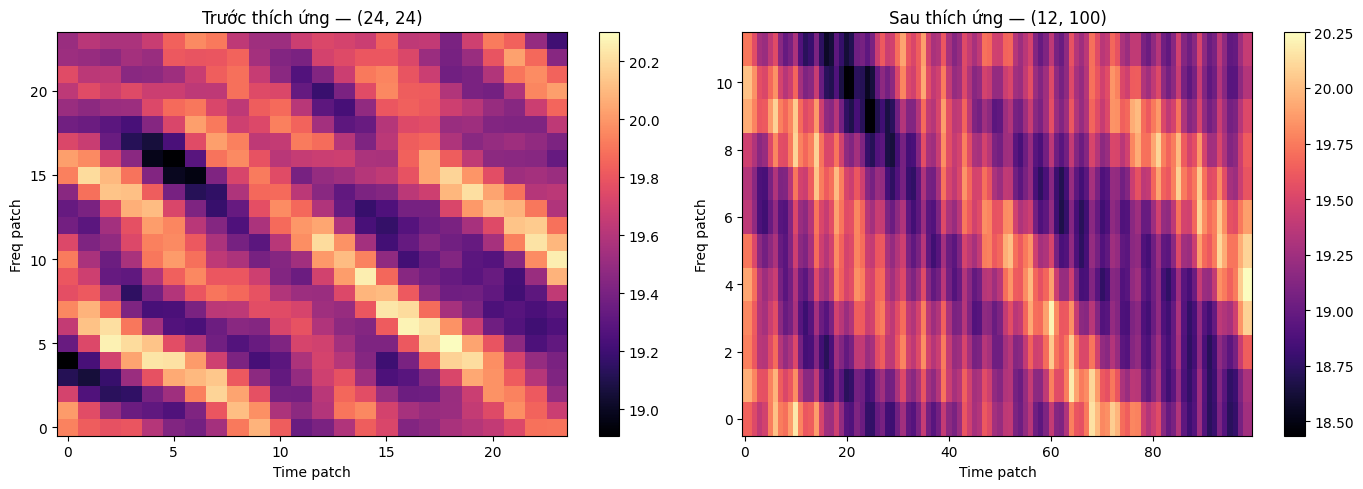

In [6]:
def positional_norm_map(pos_embed):
    # =========================================================
    # TODO 4: TÍNH CHUẨN L2 CỦA VECTOR EMBEDDING TẠI MỖI VỊ TRÍ
    # - pos_embed shape (freq, time, dim) -> trả về (freq, time)
    # - Dùng torch.linalg.norm(pos_embed, dim=-1)
    # =========================================================
    norm_map = torch.linalg.norm(pos_embed, dim=-1)
    return norm_map

norm_before = positional_norm_map(pos_embed_src)
norm_after = positional_norm_map(pos_embed_ast)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(norm_before.numpy(), origin="lower", aspect="auto", cmap="magma")
axes[0].set_title(f"Trước thích ứng — {tuple(norm_before.shape)}")
axes[0].set_xlabel("Time patch")
axes[0].set_ylabel("Freq patch")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(norm_after.numpy(), origin="lower", aspect="auto", cmap="magma")
axes[1].set_title(f"Sau thích ứng — {tuple(norm_after.shape)}")
axes[1].set_xlabel("Time patch")
axes[1].set_ylabel("Freq patch")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

## 7. Line-profile: chứng minh tính liên tục không gian

Lấy một hàng tần số cố định (sau khi đã cắt), vẽ giá trị norm theo trục thời gian **trước** (24 điểm) và **sau** (100 điểm) nội suy trên cùng một hệ trục (chuẩn hoá lại trục x về [0, 1] để so sánh hình dạng). Nếu tính liên tục được bảo toàn, đường sau nội suy phải là một phiên bản "mượt hoá/nội suy" của đường trước, không có bước nhảy hay răng cưa bất thường.

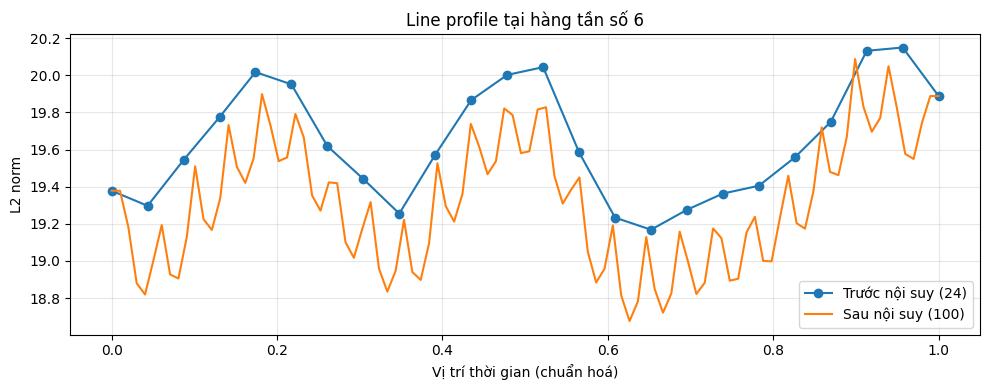

In [7]:
def plot_line_profile(pos_embed_before_crop, pos_embed_after, freq_row=None):
    # =========================================================
    # TODO 5: VẼ LINE-PROFILE TRƯỚC/SAU NỘI SUY
    # - pos_embed_before_crop: ma trận (12, 24, dim) NGAY SAU KHI CẮT TẦN SỐ
    #   nhưng TRƯỚC KHI nội suy thời gian (chính là pos_embed_freq_cropped).
    # - pos_embed_after: ma trận cuối cùng (12, 100, dim) = pos_embed_ast.
    # - Chọn 1 hàng tần số freq_row bất kỳ (mặc định hàng giữa, tức 6).
    # - Tính norm_map cho cả 2 ma trận, lấy đúng hàng freq_row.
    # - Vẽ 2 đường trên cùng 1 biểu đồ:
    #     x_before = linspace(0, 1, 24), y_before = norm hàng freq_row (trước)
    #     x_after  = linspace(0, 1, 100), y_after  = norm hàng freq_row (sau)
    # - Đặt legend, title, xlabel="Vị trí thời gian (chuẩn hoá)",
    #   ylabel="L2 norm".
    # =========================================================
    # TODO 5
    if freq_row is None:
        freq_row = pos_embed_before_crop.shape[0] // 2

    norm_before = positional_norm_map(pos_embed_before_crop)[freq_row]
    norm_after = positional_norm_map(pos_embed_after)[freq_row]

    x_before = np.linspace(0, 1, len(norm_before))
    x_after = np.linspace(0, 1, len(norm_after))

    plt.figure(figsize=(10, 4))
    plt.plot(x_before, norm_before.numpy(), "o-", label="Trước nội suy (24)")
    plt.plot(x_after, norm_after.numpy(), "-", label="Sau nội suy (100)")
    plt.title(f"Line profile tại hàng tần số {freq_row}")
    plt.xlabel("Vị trí thời gian (chuẩn hoá)")
    plt.ylabel("L2 norm")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_line_profile(pos_embed_freq_cropped, pos_embed_ast, freq_row=6)

## 8. Nhận xét

1. Vì sao trục tần số nên **cắt (crop)** còn trục thời gian nên **nội suy (interpolate)**, thay vì áp dụng cùng một chiến lược cho cả hai trục?
2. Tính liên tục không gian của positional embedding quan trọng như thế nào đối với khả năng transfer từ mô hình pretrained trên ảnh sang Spectrogram? Nếu positional embedding bị "vỡ" (gián đoạn, không mượt) sau khi resize thì điều gì có thể xảy ra với quá trình fine-tuning AST?

*(Điền câu trả lời của bạn tại đây sau khi chạy xong notebook.)*
## Nhận xét

Sau khi cắt trục tần số từ \(24\) xuống \(12\), positional embedding chỉ giữ lại vùng trung tâm của lưới gốc. Điều này phù hợp với AST vì vùng trung tâm thường ít chịu ảnh hưởng bởi các biên và vẫn bảo toàn cấu trúc không gian chính của embedding đã pretrained.

Tiếp theo, nội suy song tuyến tính mở rộng trục thời gian từ \(24\) lên \(100\). Heatmap sau nội suy vẫn thể hiện sự chuyển đổi màu mượt mà, không xuất hiện các điểm đứt gãy rõ rệt. Điều đó cho thấy tính liên tục không gian của positional embedding được duy trì khi thay đổi kích thước lưới.

Ở biểu đồ line-profile, đường sau nội suy có nhiều điểm hơn nhưng vẫn bám theo xu hướng của đường ban đầu. Các giá trị L2 norm thay đổi trơn tru theo thời gian, xác nhận rằng bilinear interpolation tạo thêm các vị trí trung gian hợp lý thay vì sao chép hoặc làm biến dạng mạnh embedding.

Như vậy, pipeline crop theo tần số kết hợp với nội suy theo thời gian cho phép tái sử dụng positional embedding từ ViT/DeiT cho AST, dù số lượng patch của spectrogram khác đáng kể so với ảnh đầu vào ban đầu.